# TP : Prédiction des frais d'assurance santé avec la régression et les KNN

## Objectif
Dans ce TP, vous allez explorer un jeu de données contenant des informations sur des personnes et leurs frais d'assurance. L'objectif est de prédire ces frais en utilisant des modèles de régression : régression linéaire et k plus proches voisins (KNN). Vous allez également analyser l'impact du nombre de voisins sur la performance du modèle KNN.

# 1. Importation des bibliothèques
Importer les bibliothèques nécessaires pour manipuler les données, les visualiser et construire les modèles de machine learning.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.neighbors import KNeighborsRegressor

from random import randint


# 2. Chargement des données
Charger les données depuis le fichier insurance.csv disponible sur moodle.

In [95]:
df = pd.read_csv('insurance.csv')

# 3. Exploration des données
Analyser les premières lignes du dataset et quelques statistiques générales.

## Afficher les premières lignes du dataset

In [96]:
print(df.head(10))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692


## Afficher des statistiques générales sur les variables numériques

In [97]:
df.describe()



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Vérifier les valeurs manquantes

In [98]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Visualiser la distribution de la variable cible (charges) 

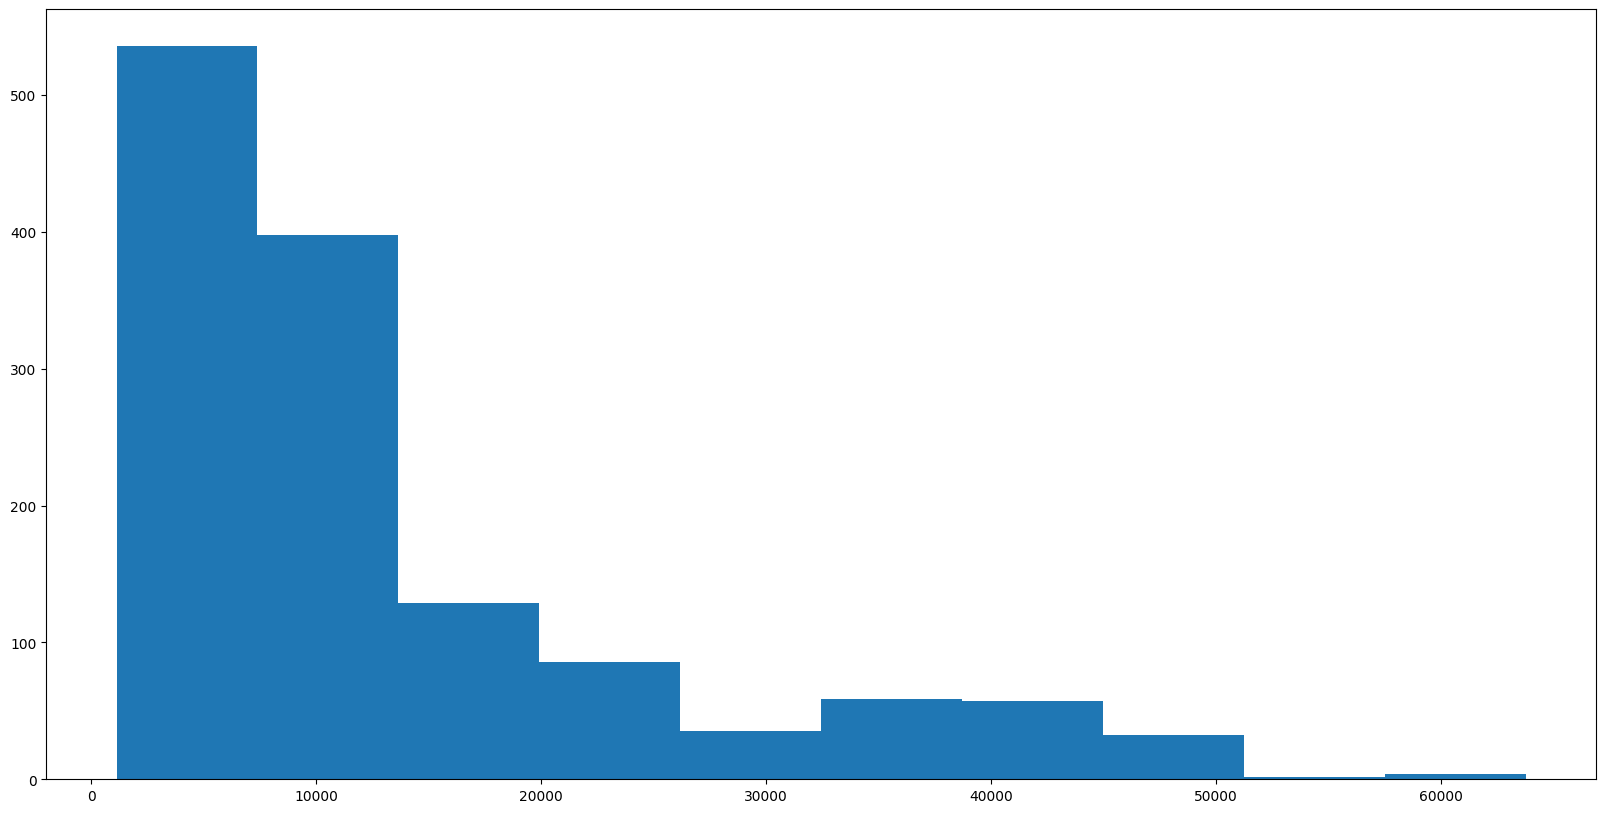

In [99]:
plt.figure(figsize=(20,10))
plt.hist(df['charges'])
plt.show()

# 4. Prétraitement des données
### Encodage des variables catégorielles
Transformer les variables catégorielles en variables numériques avec `OneHotEncoder`.

In [100]:
encoder = OneHotEncoder(sparse_output=False)

df['sex'] = encoder.fit_transform(df[['sex']])
df['smoker'] = encoder.fit_transform(df[['smoker']])
df['region'] = LabelEncoder().fit_transform(df[['region']])


C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Normalisation des variables numériques
Normaliser les variables numériques pour les mettre à l'échelle.

In [101]:
scaler = StandardScaler()

columns = ['bmi', 'age', 'children']

for col in columns:
    df[col] = scaler.fit_transform(df[[col]])

print(df)


           age  sex       bmi  children  smoker  region      charges
0    -1.438764  1.0 -0.453320 -0.908614     0.0       3  16884.92400
1    -1.509965  0.0  0.509621 -0.078767     1.0       2   1725.55230
2    -0.797954  0.0  0.383307  1.580926     1.0       2   4449.46200
3    -0.441948  0.0 -1.305531 -0.908614     1.0       1  21984.47061
4    -0.513149  0.0 -0.292556 -0.908614     1.0       1   3866.85520
...        ...  ...       ...       ...     ...     ...          ...
1333  0.768473  0.0  0.050297  1.580926     1.0       1  10600.54830
1334 -1.509965  1.0  0.206139 -0.908614     1.0       0   2205.98080
1335 -1.509965  1.0  1.014878 -0.908614     1.0       2   1629.83350
1336 -1.296362  1.0 -0.797813 -0.908614     1.0       3   2007.94500
1337  1.551686  1.0 -0.261388 -0.908614     0.0       1  29141.36030

[1338 rows x 7 columns]


### Construction du dataset final
Assembler les variables encodées et normalisées pour créer la matrice des caractéristiques `X` et la variable cible `y`.

In [102]:
y = df['charges'].values
X = df.drop(columns=['charges']).values

print(X.shape)
print(y.shape)

(1338, 6)
(1338,)


# 5. Division en ensembles d'entraînement et de test
Séparer les données en un ensemble d'entraînement (80%) et un ensemble de test (20%).

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randint(1,100))

# 6. Implémentation d'un modèle de régression linéaire
Créer et entraîner un modèle de régression linéaire.

In [13]:
linearRegression = LinearRegression()

linearRegression.fit(X_train, y_train)

y_pred_train = linearRegression.predict(X_train)
y_pred_test = linearRegression.predict(X_test)

# 7. Prédictions et évaluation du modèle linéaire
Évaluer les performances du modèle avec l'erreur quadratique moyenne (MSE) et le coefficient de détermination (R²) sur le dataset d'entrainement et de test. Que pensez-vous de la qualité de ce modèle?

In [14]:
print(f'MAE train : {mean_absolute_error(y_train, y_pred_train)}')
print(f'MAE test : {mean_absolute_error(y_test, y_pred_test)}')

print(f'MSE train : {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE test : {mean_squared_error(y_test, y_pred_test)}')

MAE train : 4291.931565986592
MAE test : 3826.9609823608703
MSE train : 37091593.55726334
MSE test : 34596970.39240098


# 8. Implémentation d'un modèle KNN
Créer, entraîner et évaluer un modèle KNN avec `k=5`.

In [15]:
knnR = KNeighborsRegressor(n_neighbors = 5)
knnR.fit(X_train, y_train)

y_pred_train = knnR.predict(X_train)
y_pred_test = knnR.predict(X_test)

print(f'MAE train : {mean_absolute_error(y_train, y_pred_train)}')
print(f'MAE test : {mean_absolute_error(y_test, y_pred_test)}')

print(f'MSE train : {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE test : {mean_squared_error(y_test, y_pred_test)}')

MAE train : 3011.005858348411
MAE test : 3813.4781634768656
MSE train : 26070110.782261316
MSE test : 46322582.562086985


# 9. Étude de l'impact du nombre de voisins
Tester l'effet du nombre de voisins sur la performance du modèle KNN.
Vous devez produire un graphique qui affiche la MSE en ordonnées en fonction du nombre voisin (en abscisse). Les valeurs en entrainement et en test doivent être affichées

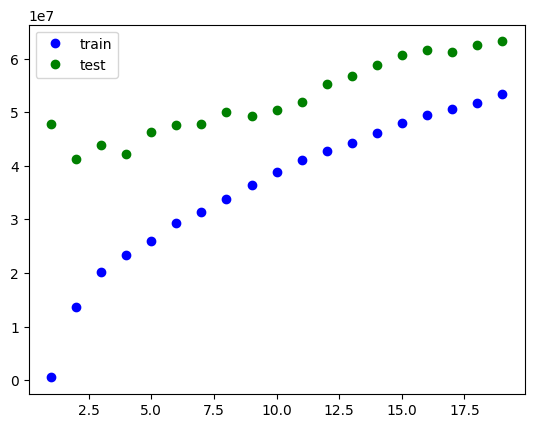

In [16]:
mse_train = []
mse_test = []

plt.figure(10)

k_values = [i for i in range(1,20)]

mse_test = []
mse_train = []

for i in range(1, 20):
    knnR = KNeighborsRegressor(n_neighbors = i)
    knnR.fit(X_train, y_train)

    y_pred_train = knnR.predict(X_train)
    y_pred_test = knnR.predict(X_test)

    mse_train.append(mean_squared_error(y_train, y_pred_train))
    mse_test.append(mean_squared_error(y_test, y_pred_test))

plt.plot(k_values, mse_train, 'ob', label='train')
plt.plot(k_values, mse_test, 'og', label='test')     

plt.xlabel = "Neighbors number"
plt.ylabel = "MSE value"

plt.legend()

plt.show()

# Fonctions générique pour trouver le meilleur algo de regression

In [22]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### KNN

In [24]:
from sklearn.neighbors import KNeighborsRegressor

In [23]:
def get_best_knn_regressor(X_train, y_train, X_test, y_test, param_grid_knn):
    result = {}
    result['knn'] = {}
    knn = KNeighborsRegressor()
    knn.fit(X_train, y_train)

    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['knn']['default'] = {'train': mae_train, 'test': mae_test}

    grid_search = GridSearchCV(estimator=knn, scoring='neg_mean_absolute_error', param_grid=param_grid_knn, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    knn_best_params = grid_search.best_params_

    knn_best = grid_search.best_estimator_
    y_pred_train = knn_best.predict(X_train)
    y_pred_test = knn_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['knn']['best'] = {'params':knn_best_params, 'train': mae_train, 'test': mae_test}
    return result

In [25]:
param_grid_knn = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_result = get_best_knn_regressor(X_train, y_train, X_test, y_test, param_grid_knn)

### SVM

In [32]:
from sklearn.svm import SVR

In [36]:
def get_best_svm_regressor(X_train, y_train, X_test, y_test, param_grid_svm):
    result = {}
    result['SVM'] = {}
    svm = SVR()
    svm.fit(X_train, y_train)

    y_pred_train = svm.predict(X_train)
    y_pred_test = svm.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['SVM']['default'] = {'train': mae_train, 'test': mae_test}

    grid_search = GridSearchCV(estimator=svm, scoring='neg_mean_absolute_error', param_grid=param_grid_svm, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    svm_best_params = grid_search.best_params_

    svm_best = grid_search.best_estimator_
    y_pred_train = svm_best.predict(X_train)
    y_pred_test = svm_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['SVM']['best'] = {'params':svm_best_params, 'train': mae_train, 'test': mae_test}
    return result

In [38]:
param_grid_svm = {
    'C': [00.1, 0.1, 1],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['poly'],
    'degree': [2,3]
}

svm_result = get_best_svm_regressor(X_train, y_train, X_test, y_test, param_grid_svm)

### Decision Tree

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [42]:
def get_best_decision_tree_regressor(X_train, y_train, X_test, y_test, param_grid_decision_tree):
    result = {}
    result['DecisionTree'] = {}
    decision_tree = DecisionTreeRegressor()
    decision_tree.fit(X_train, y_train)

    y_pred_train = decision_tree.predict(X_train)
    y_pred_test = decision_tree.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['DecisionTree']['default'] = {'train': mae_train, 'test': mae_test}

    grid_search = GridSearchCV(estimator=decision_tree, scoring='neg_mean_absolute_error', param_grid=param_grid_decision_tree, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    decision_tree_best_params = grid_search.best_params_

    decision_tree_best = grid_search.best_estimator_
    y_pred_train = decision_tree_best.predict(X_train)
    y_pred_test = decision_tree_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['DecisionTree']['best'] = {'params':decision_tree_best_params, 'train': mae_train, 'test': mae_test}

    return result

In [44]:
param_grid_decision_tree = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2']
}

decision_tree_result = get_best_decision_tree_regressor(X_train, y_train, X_test, y_test, param_grid_decision_tree)

### Random Forest

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
def get_best_random_forest_regressor(X_train, y_train, X_test, y_test, param_grid_random_forest):
    result = {}
    result['RandomForest'] = {}
    random_forest = RandomForestRegressor()
    random_forest.fit(X_train, y_train)

    y_pred_train = random_forest.predict(X_train)
    y_pred_test = random_forest.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['RandomForest']['default'] = {'train': mae_train, 'test': mae_test}

    randomized_search = RandomizedSearchCV(estimator=random_forest, scoring='neg_mean_absolute_error', param_distributions=param_grid_random_forest, cv=5, n_jobs=-1, n_iter=500)
    randomized_search.fit(X_train, y_train)

    random_forest_best_params = randomized_search.best_params_

    random_forest_best = randomized_search.best_estimator_
    y_pred_train = random_forest_best.predict(X_train)
    y_pred_test = random_forest_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['RandomForest']['best'] = {'params':random_forest_best_params, 'train': mae_train, 'test': mae_test}

    return result

In [49]:
param_grid_random_forest = {
    'n_estimators': [20,100,200,300],
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_forest_result = get_best_random_forest_regressor(X_train, y_train, X_test, y_test, param_grid_random_forest)

### XGBoost

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

In [57]:
def get_best_xgboost_regressor(X_train, y_train, X_test, y_test, param_grid_xgboost):
    result = {}
    result['XGBoost'] = {}
    xgboost = GradientBoostingRegressor()
    xgboost.fit(X_train, y_train)

    y_pred_train = xgboost.predict(X_train)
    y_pred_test = xgboost.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['XGBoost']['default'] = {'train': mae_train, 'test': mae_test}

    randomized_search = RandomizedSearchCV(estimator=xgboost, scoring='neg_mean_absolute_error', param_distributions=param_grid_xgboost, cv=5, n_jobs=-1, n_iter=500)
    randomized_search.fit(X_train, y_train)

    xgboost_best_params = randomized_search.best_params_

    xgboost_best = randomized_search.best_estimator_
    y_pred_train = xgboost_best.predict(X_train)
    y_pred_test = xgboost_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['XGBoost']['best'] = {'params':xgboost_best_params, 'train': mae_train, 'test': mae_test}

    return result

In [58]:
param_grid_xgboost = {
    "n_estimators" : [25, 50, 100, 200],
    "learning_rate" : [0.01, 0.1, 0.3],
    "max_depth" : [3, 4, 5, 6],
    "tol" : [0.0001, 0.001, 0.01, 1, 2, 3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features" : [None, "sqrt", "log2"]
}

xgboost_result = get_best_xgboost_regressor(X_train, y_train, X_test, y_test, param_grid_xgboost)

### Tableau

In [59]:
all_result = [knn_result, svm_result, decision_tree_result, random_forest_result, xgboost_result]

In [60]:
def generate_markdown_table_from_list_for_regressor(results_list):
    markdown_table = "| Algo | Hyperparams | Train MAE | Test MAE |\n"
    markdown_table += "|:----:|:-----------:|:-----:|:----:|\n"

    for result in results_list:
        for algo, result_dict in result.items():
            for key, values in result_dict.items():
                if key == 'default':
                    hyperparams = 'default'
                else:
                    hyperparams = values.get('params', '-')
                
                train_mae = round(values['train'], 4)
                test_mae = round(values['test'], 4)
                
                markdown_table += f"| {algo} | {hyperparams} | {train_mae} | {test_mae} |\n"
    
    return markdown_table

In [61]:
markdown_table = generate_markdown_table_from_list_for_regressor(all_result)
print(markdown_table)

| Algo | Hyperparams | Train MAE | Test MAE |
|:----:|:-----------:|:-----:|:----:|
| knn | default | 3011.0059 | 3813.4782 |
| knn | {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | 29.5725 | 3638.1794 |
| SVM | default | 8356.1174 | 8193.6687 |
| SVM | {'C': 1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'} | 8279.4662 | 8111.9174 |
| DecisionTree | default | 29.5725 | 3012.3115 |
| DecisionTree | {'criterion': 'absolute_error', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10} | 1480.3512 | 1586.4952 |
| RandomForest | default | 1018.0883 | 2628.5627 |
| RandomForest | {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 20, 'criterion': 'absolute_error', 'bootstrap': True} | 1621.6091 | 1598.208 |
| XGBoost | default | 2027.3971 | 2398.6929 |
| XGBoost | {'tol': 0.0001, 'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'l

| Algo | Hyperparams | Train MAE | Test MAE |
|:----:|:-----------:|:-----:|:----:|
| knn | default | 3011.0059 | 3813.4782 |
| knn | {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | 29.5725 | 3638.1794 |
| SVM | default | 8356.1174 | 8193.6687 |
| SVM | {'C': 1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'} | 8279.4662 | 8111.9174 |
| DecisionTree | default | 29.5725 | 3012.3115 |
| DecisionTree | {'criterion': 'absolute_error', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10} | 1480.3512 | 1586.4952 |
| RandomForest | default | 1018.0883 | 2628.5627 |
| RandomForest | {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 20, 'criterion': 'absolute_error', 'bootstrap': True} | 1621.6091 | 1598.208 |
| XGBoost | default | 2027.3971 | 2398.6929 |
| XGBoost | {'tol': 0.0001, 'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.3} | 2133.9685 | 2433.8768 |


### Neural Network

In [67]:
from sklearn.neural_network import MLPRegressor

Neural network avec 2 couches cachées (la première avec 64 neuronnes et la deuxième avec 32 neuronnes) avec une fonction d'activation ReLU

In [68]:
mlp = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(mae_test, mae_train)

2909.5810099162222 3230.638879578013


C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural network avec 3 couches cachées (la première avec 128 neuronnes, la deuxième avec 64 neuronnes et la troisième avec 32 neuronnes) avec une fonction d'activation ReLU

In [66]:
mlp = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(mae_test, mae_train)

2645.8801236113954 2385.890051431726


| Algo | Hyperparams | Train MAE | Test MAE |
|:----:|:-----------:|:-----:|:----:|
| knn | default | 3011.0059 | 3813.4782 |
| knn | {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | 29.5725 | 3638.1794 |
| SVM | default | 8356.1174 | 8193.6687 |
| SVM | {'C': 1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'} | 8279.4662 | 8111.9174 |
| DecisionTree | default | 29.5725 | 3012.3115 |
| DecisionTree | {'criterion': 'absolute_error', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10} | 1480.3512 | 1586.4952 |
| RandomForest | default | 1018.0883 | 2628.5627 |
| RandomForest | {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 20, 'criterion': 'absolute_error', 'bootstrap': True} | 1621.6091 | 1598.208 |
| XGBoost | default | 2027.3971 | 2398.6929 |
| XGBoost | {'tol': 0.0001, 'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.3} | 2133.9685 | 2433.8768 |
| Neural Network | hidden_layer_sizes=(64,32), activation='relu', max_iter=1000 | 2909.581 | 3230.6388 |
| Neural Network | hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000 | 2645.8801 | 2385.89 |


# Feature selection

### Matrice de corrélation

In [123]:
X_columns = df.drop(columns=['charges']).columns

<Axes: >

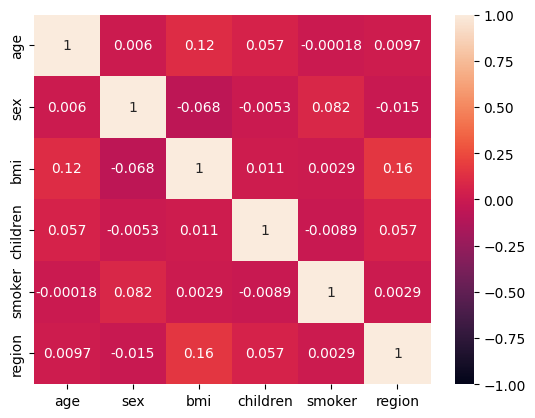

In [124]:
import seaborn as sns

insurance_df = pd.DataFrame(data=X_train, columns=X_columns)

matrix = insurance_df.corr()

sns.heatmap(matrix, annot=True, vmin=-1, vmax=1)

-> Très peu de corrélation entre les features

### Feature selection avec Boruta

In [133]:
# TODO

# Explicabilité

In [125]:
best_random_forest = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=6, max_features=None, max_depth=20, criterion='absolute_error', bootstrap=True)
best_random_forest.fit(X_train, y_train)

RandomForestRegressor(criterion='absolute_error', max_depth=20,
                      max_features=None, min_samples_leaf=6,
                      min_samples_split=10)

In [126]:
import shap

explainer = shap.Explainer(best_random_forest)
shap_values = explainer.shap_values(X_test)

### Bar plot

TypeError: 'str' object is not callable

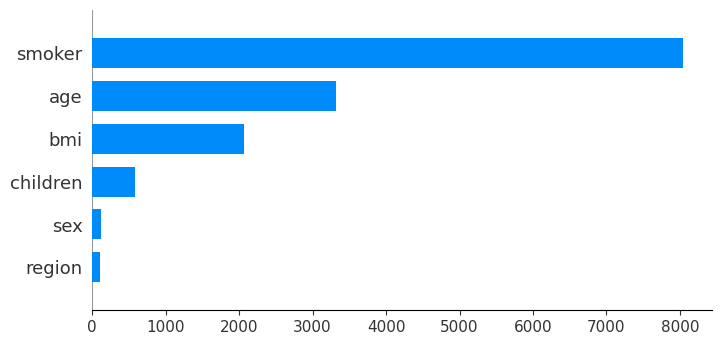

In [127]:
shap.summary_plot(shap_values[:,:], X_test, feature_names=t, plot_type='bar')

### Summary plot

TypeError: 'str' object is not callable

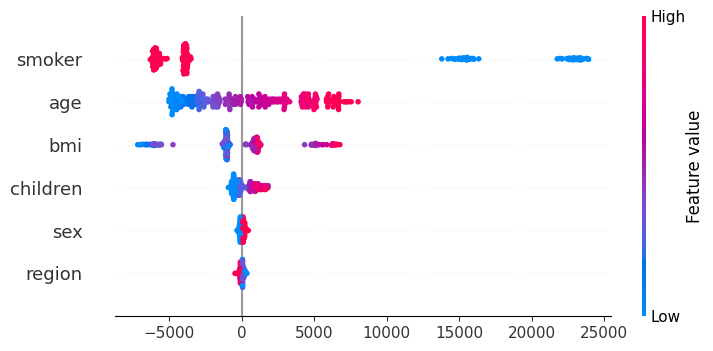

In [129]:
shap.summary_plot(shap_values[:,:], X_test, feature_names=X_columns)

Moins on fume, + on a de charges

### Waterfall plot

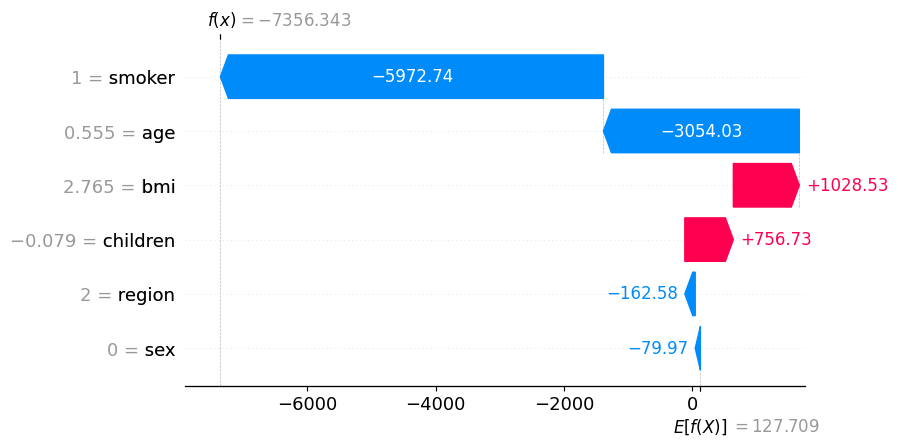

In [132]:
instance_idx=20
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_idx, :],
                                    base_values=shap_values.mean(),
                                    data=X_train[instance_idx],
                                    feature_names=X_columns)     
                    )